#### Diamonds 가격 비교

In [1]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import numpy as np

In [2]:
from sklearn import set_config
set_config(display='text')

In [5]:
df = pd.read_csv('../ai_data/diamonds.csv')
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [4]:
# carat과 price 열에 대한 결측치 확인 (값 = 0 & 값 = Na)
columns_0 = ['carat', 'price']

for column in columns_0 :
    df[column] = df[column].replace(0, np.nan)

# 결측치 없는 것으로 확인!
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [13]:
# carat의 이상치 경계를 확인하고, 이상치 데이터는 평균값으로 대체
Q1_carat = df['carat'].quantile(0.25)
Q3_carat = df['carat'].quantile(0.75)
IQR_carat = Q3_carat - Q1_carat

low_carat = Q1_carat - 1.5 * IQR_carat
up_carat = Q3_carat + 1.5 * IQR_carat

mean_carat = df['carat'].mean()

df.loc[ df['carat'] < low_carat, 'carat'] = mean_carat
df.loc[ df['carat'] > up_carat, 'carat'] = mean_carat


In [14]:
# price의 이상치 경계를 확인하고, 이상치 데이터는 평균값으로 대체
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

low_price = Q1_price - 1.5 * IQR_price
up_price = Q3_price + 1.5 * IQR_price

mean_price = df['price'].mean()

df['price'] = df['price'].astype(float)
df.loc[ df['price'] < low_price, 'price'] = mean_price
df.loc[ df['price'] > up_price, 'price'] = mean_price

In [ ]:
# 학습용 데이터와 테스트용 데이터 설정
X_carat = df[['carat']]
y = df['price']

X_train_carat, X_test_carat, y_train, y_test = train_test_split(
    X_carat, y,
    test_size = 0.2,
    random_state = 42
)

In [9]:
import matplotlib.pyplot as plt

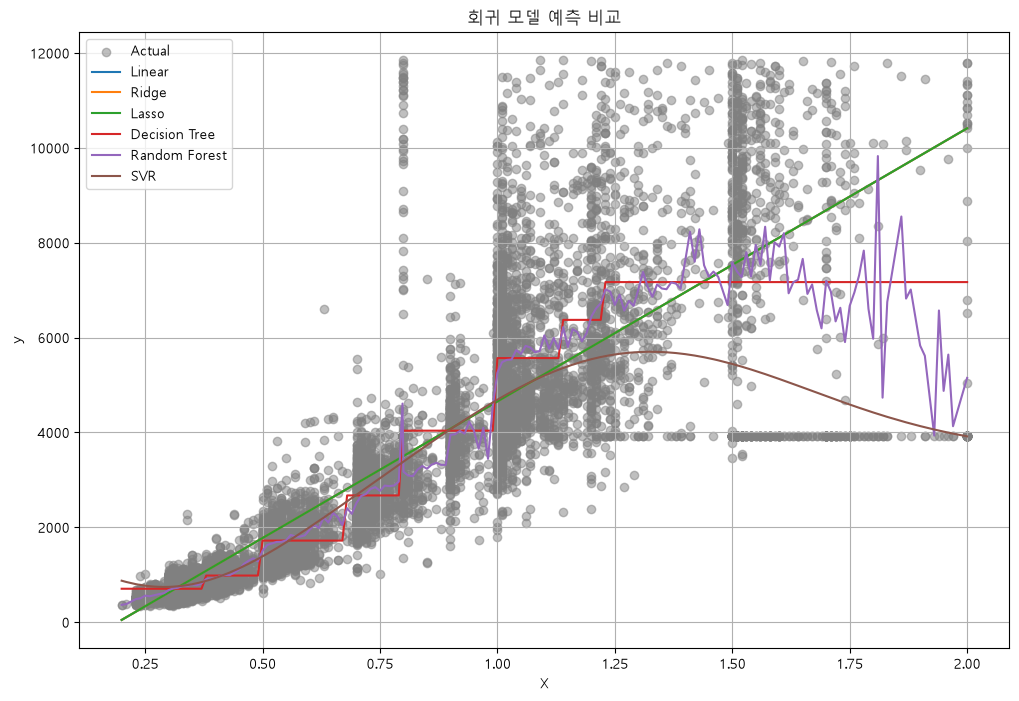

           Model           MSE        R2
4  Random Forest  1.619784e+06  0.769978
3  Decision Tree  1.672466e+06  0.762497
1          Ridge  1.983004e+06  0.718398
2          Lasso  1.983011e+06  0.718397
0         Linear  1.983032e+06  0.718394
5            SVR  2.173448e+06  0.691353


In [17]:
# dict 형태로 여러 가지 모델 생성
models = {
    'Linear' : LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'Lasso' : Lasso(alpha=0.1),
    'Decision Tree' : DecisionTreeRegressor(max_depth=3),
    'Random Forest' : RandomForestRegressor(n_estimators=100),
    'SVR' : SVR()
}

# 학습 및 예측 결과 저장
results = []

plt.figure(figsize=(12, 8))
plt.scatter(X_test_carat, y_test, color='gray', alpha=0.5, label="Actual")

for name, model in models.items():
    model.fit(X_train_carat, y_train)
    y_pred = model.predict(X_test_carat)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })
    
    # 예측선 시각화 ( 1차원 배열로 변환 )
    X_arr = X_test_carat.values.flatten()
    sorted_idx = np.argsort(X_arr)
    plt.plot(X_arr[sorted_idx], y_pred[sorted_idx], label=name)

# 한글화 및 라벨링
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title("회귀 모델 예측 비교")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 모델 성능 비교 출력
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(df_results)